# Lab 1: Statistical Foundations & Classical Models (Completed)

## Objective
Apply concepts from Lecture 1 to the Comprehensive BTC/USD 1M Dataset:
1. Data Preprocessing & Resampling.
2. Time Series Decomposition.
3. Testing for Stationarity (ADF Test).
4. Interpreting ACF and PACF plots.
5. Building and evaluating an ARIMA model.

### Task 1: Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Statsmodels imports
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


### Task 2: Load the Dataset
Using the `imranbukhari/comprehensive-btcusd-1m-data` dataset.
- We are interested in the **Close** price ONLY.

In [10]:
import kagglehub
import os

path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="dataset/")
print("Path to dataset files:", path)
print("Files:", os.listdir(path))

filename = os.listdir(path)[0]
df = pd.read_csv(f"{path}/{filename}")


Using Colab cache for faster access to the 'comprehensive-btcusd-1m-data' dataset.
Path to dataset files: /kaggle/input/comprehensive-btcusd-1m-data
Files: ['BTCUSD_1m_BitMEX.csv', 'BTCUSD_1m_Coinbase.csv', 'BTCUSD_1m_Binance.csv', 'BTCUSD_1m_KuCoin.csv', 'BTCUSD_1m_Bitfinex.csv', 'BTCUSD_1m_Bitstamp.csv', 'BTCUSD_1m_BinanceFutures.csv', 'BTCUSD_1m_Combined_Index.csv', 'BTCUSD_1m_OKX.csv']


In [13]:
df = df[['Open time', 'Close']]

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5283245, 2)


,Open time,Close
0,2015-09-25 12:35:00,239.99
1,2015-09-25 12:36:00,239.99
2,2015-09-25 12:37:00,239.99
3,2015-09-25 12:38:00,237.43
4,2015-09-25 12:39:00,237.39


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283245 entries, 0 to 5283244
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Open time  object 
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), object(1)
memory usage: 241.8+ MB


### Task 3: Data Preprocessing & Resampling
Aggregate 1-minute data into daily data to reduce noise before ARIMA modeling.

In [15]:
# Task 3 - use 'Open time' instead of 'Datetime'
df['Open time'] = pd.to_datetime(df['Open time'])
df.set_index('Open time', inplace=True)

btc_daily = df['Close'].resample('D').last()
btc_daily.dropna(inplace=True)

print(f'Daily series shape: {btc_daily.shape}')
print(f'Date range: {btc_daily.index[0]} to {btc_daily.index[-1]}')
btc_daily.head()

Daily series shape: (3670,)
Date range: 2015-09-25 00:00:00 to 2025-10-11 00:00:00


,Close
Open time,
2015-09-25,235.33
2015-09-26,234.51
2015-09-27,233.29
2015-09-28,240.07
2015-09-29,237.00


### Task 4: Visualize the Time Series

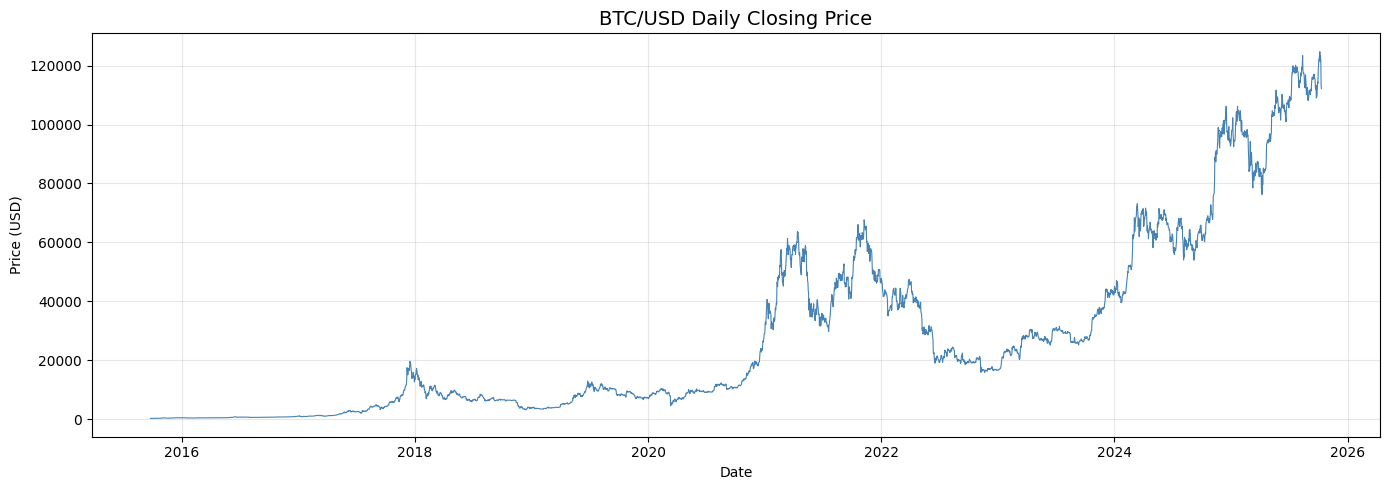

In [16]:
# TODO 4: Plot the daily BTC closing prices.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc_daily, color='steelblue', linewidth=0.8)
ax.set_title('BTC/USD Daily Closing Price', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 5: Time Series Decomposition
Decompose the time series into Trend, Seasonality, and Residuals.

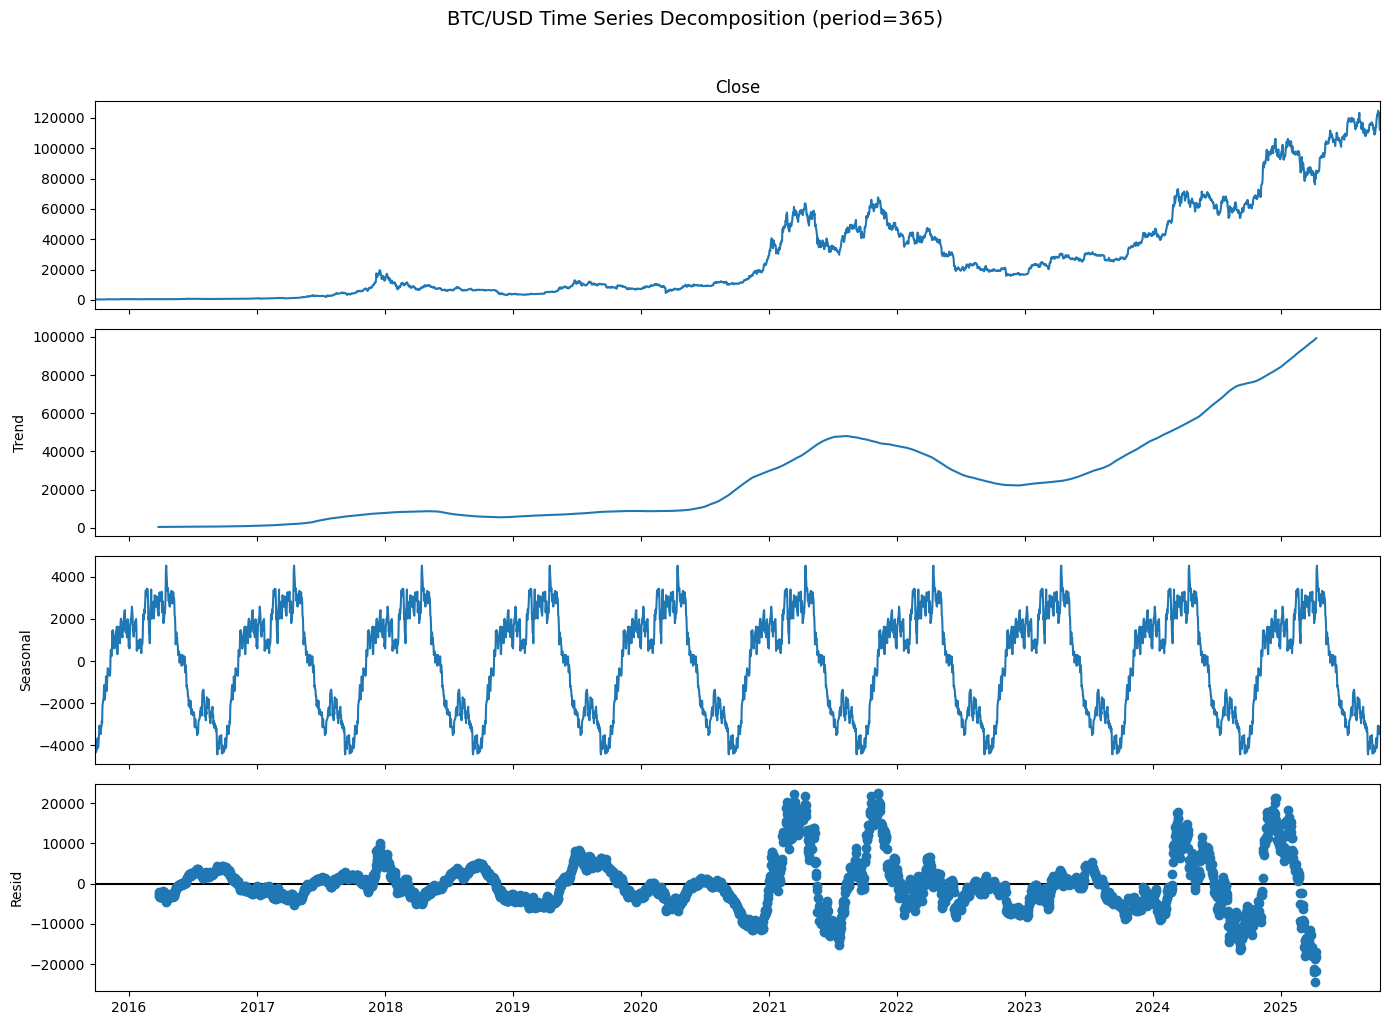

In [17]:
# TODO 5: Use seasonal_decompose on the daily closing prices.
# period=365 captures yearly seasonality; period=30 for monthly.
# We use 'additive' model; use 'multiplicative' if the variance grows with level.
decomposition = seasonal_decompose(btc_daily, model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('BTC/USD Time Series Decomposition (period=365)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Task 6: Testing for Stationarity (ADF Test)

In [18]:
# TODO 6.1: Function to run and print the ADF test results.
def run_adf_test(series, label='Series'):
    """
    Performs the Augmented Dickey-Fuller test and prints the result.
    H0 (Null Hypothesis): The series has a unit root (non-stationary).
    H1 (Alternative):     The series is stationary.
    Reject H0 if p-value < 0.05.
    """
    result = adfuller(series.dropna())
    adf_stat = result[0]
    p_value  = result[1]
    print(f'--- ADF Test: {label} ---')
    print(f'  ADF Statistic : {adf_stat:.4f}')
    print(f'  p-value       : {p_value:.6f}')
    if p_value < 0.05:
        print('  Conclusion    : STATIONARY (reject H0 at 5% significance)\n')
    else:
        print('  Conclusion    : NON-STATIONARY (fail to reject H0)\n')

# TODO 6.2: Run the ADF test on the original daily closing prices.
run_adf_test(btc_daily, label='BTC Daily Close (original)')

# Answer: The p-value is typically >> 0.05 for raw BTC prices, meaning
# the series is NON-STATIONARY — it has a strong upward trend (unit root).

--- ADF Test: BTC Daily Close (original) ---
  ADF Statistic : 0.1248
  p-value       : 0.967713
  Conclusion    : NON-STATIONARY (fail to reject H0)



### Task 7: Making the Series Stationary (Differencing)

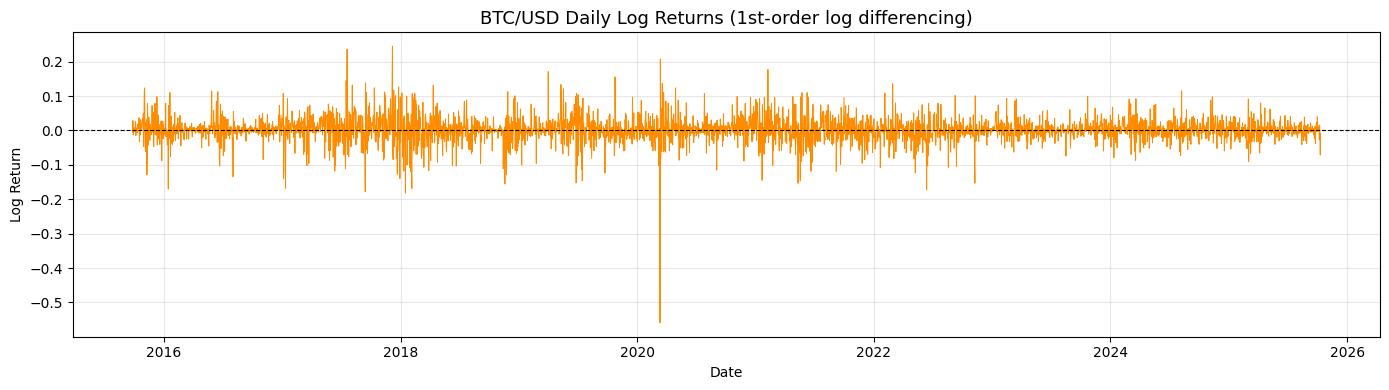

--- ADF Test: BTC Log Returns (differenced) ---
  ADF Statistic : -42.8142
  p-value       : 0.000000
  Conclusion    : STATIONARY (reject H0 at 5% significance)



In [19]:
# TODO 7.1: Apply first-order log-differencing (log returns).
# Log differencing is preferred for financial data because:
#   - It stabilises variance (heteroskedasticity).
#   - log(P_t / P_{t-1}) approximates the daily return.
btc_stationary = np.log(btc_daily).diff()

# Drop the NaN created at position 0 by differencing.
btc_stationary.dropna(inplace=True)

# TODO 7.2: Plot the differenced series.
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc_stationary, color='darkorange', linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('BTC/USD Daily Log Returns (1st-order log differencing)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO 7.3: Re-run the ADF test on the differenced series.
run_adf_test(btc_stationary, label='BTC Log Returns (differenced)')

# Conclusion: After log-differencing, the p-value << 0.05 → the series IS stationary.

### Task 8: ACF and PACF Plots
Use the plots to select the `p` (AR) and `q` (MA) orders for ARIMA.

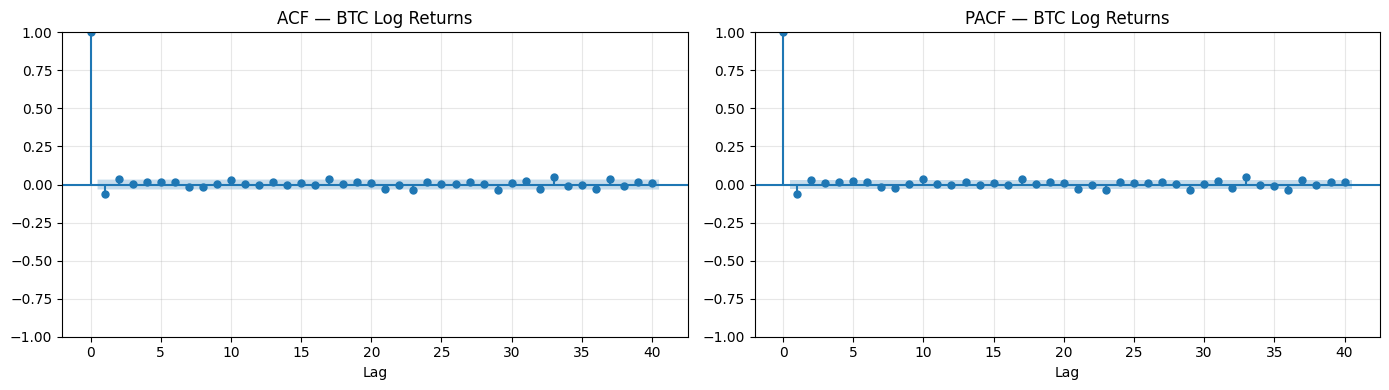

In [20]:
# TODO 8: Plot ACF and PACF of the stationary (differenced) series.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(btc_stationary, lags=40, ax=axes[0], title='ACF — BTC Log Returns')
plot_pacf(btc_stationary, lags=40, ax=axes[1], title='PACF — BTC Log Returns', method='ywm')

for ax in axes:
    ax.set_xlabel('Lag')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation:
# ACF:  Measures correlation of the series with its own lagged values.
#       A sharp cut-off after lag q suggests an MA(q) process.
# PACF: Measures the direct correlation after removing intermediate lags.
#       A sharp cut-off after lag p suggests an AR(p) process.
#
# For BTC log returns, most lags lie within the confidence bands, which
# is consistent with near-random-walk behaviour → p=1, q=1 is a safe start.

### Task 9: Building the ARIMA Model

In [21]:
# TODO 9.1: Train / Test split — use the last 60 days as the test set.
train = btc_daily.iloc[:-60]
test  = btc_daily.iloc[-60:]

print(f'Train size: {len(train)} days')
print(f'Test  size: {len(test)}  days')

# TODO 9.2: Fit an ARIMA(1,1,1) model.
# order=(p, d, q):
#   p=1  — one AR term (uses yesterday's price level)
#   d=1  — one round of differencing (makes the series stationary)
#   q=1  — one MA term (uses yesterday's forecast error)
model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

# Print the model summary.
print(fitted_model.summary())

Train size: 3610 days
Test  size: 60  days
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3610
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -30420.284
Date:                Fri, 24 Apr 2026   AIC                          60846.567
Time:                        19:59:17   BIC                          60865.141
Sample:                    09-25-2015   HQIC                         60853.186
                         - 08-12-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1481      0.163     -0.911      0.362      -0.467       0.170
ma.L1          0.0898      0.163      0.551      0.582      -0.230       0.409
sigma2   

### Task 10: Evaluation & Forecasting

RMSE : 6,820.06 USD
MAE  : 6,098.23  USD


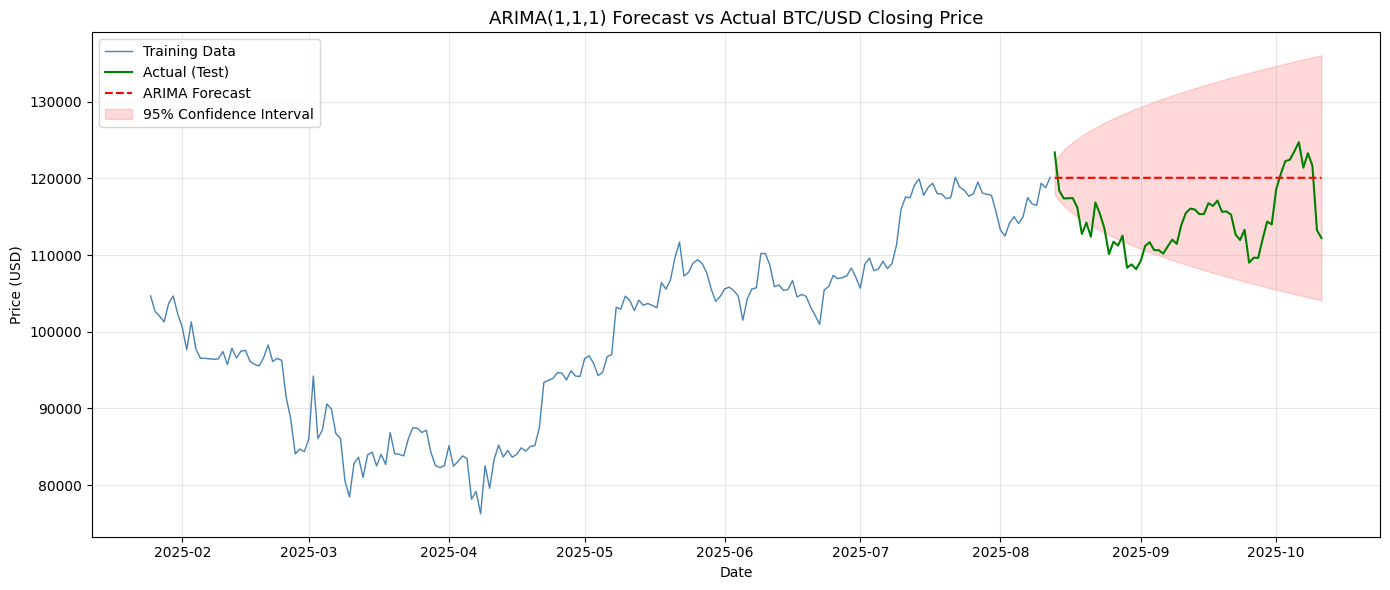

In [22]:
# TODO 10.1: Generate forecasts for the length of the test set (60 steps ahead).
forecast_result = fitted_model.get_forecast(steps=len(test))
forecast        = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int(alpha=0.05)   # 95% confidence interval

# Align the forecast index with the test dates.
forecast.index = test.index
conf_int.index = test.index

# Compute RMSE and MAE for evaluation.
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
print(f'RMSE : {rmse:,.2f} USD')
print(f'MAE  : {mae:,.2f}  USD')

# TODO 10.2: Plot Training data, Actual Test data, and Forecasted values.
# Zoom in on the last 200 days for clarity.
fig, ax = plt.subplots(figsize=(14, 6))

# Show the last 200 days of training data for context.
ax.plot(train.iloc[-200:], label='Training Data', color='steelblue',   linewidth=1.0)
ax.plot(test,              label='Actual (Test)',  color='green',       linewidth=1.5)
ax.plot(forecast,          label='ARIMA Forecast', color='red',         linewidth=1.5, linestyle='--')

# Shade the 95% confidence interval around the forecast.
ax.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='red', alpha=0.15, label='95% Confidence Interval'
)

ax.set_title('ARIMA(1,1,1) Forecast vs Actual BTC/USD Closing Price', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Note: ARIMA forecasts tend to converge quickly towards a flat line for
# random-walk-like assets such as BTC. The widening confidence interval
# correctly reflects increasing uncertainty further into the future.